<a href="https://colab.research.google.com/github/kraseliukts/data_analysis_wine_company/blob/main/Data_analysis_wine_company_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DATA ANALYSIS

**Data Analyst - Tatiana Kraseliuk.**

**Objective:** Analyze data provided by fictios wine company "Bodegas Martínez", performing all necessary cleansing process and present an engaging story that summarizes the key trends.

## 1.Data cleaning and preprocessing

#### Data loading, reading and cleansing process

In [1]:
# import all necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

In [55]:
# read the data files, loaded to git hub repository
url_1="https://github.com/kraseliukts/data_analysis_wine_company/raw/main/Actividad2.BodegasMartinez_parte1.xlsx"
url_2="https://github.com/kraseliukts/data_analysis_wine_company/raw/main/Actividad2.BodegasMartinez_parte2.xlsx"
url_3="https://github.com/kraseliukts/data_analysis_wine_company/raw/main/Actividad2.BodegasMartinez_parte3.xlsx"

In [56]:
#visualize excel sheet names

print("Sheet names, file 1: ", pd.ExcelFile(url_1).sheet_names, '\n',
      "Sheet names, file 2: ", pd.ExcelFile(url_2).sheet_names, '\n',
      "Sheet names, file 3: ", pd.ExcelFile(url_3).sheet_names)

Sheet names, file 1:  ['Hoja1', 'Sheet1'] 
 Sheet names, file 2:  ['Sheet1'] 
 Sheet names, file 3:  ['Sheet1']


##### Data reading and cleansing process, file #1

In [57]:
#read the file, excel sheet "Sheet1"
data_1=pd.read_excel(url_1, engine='openpyxl', sheet_name="Sheet1")
data_1.head(5)

,Código Cliente,Tipo establecimiento,Zona,Código Producto,Familia,Año-Mes,Euros,Botellas,Precio Medio,Unnamed: 9,Unnamed: 10
0,100122815,COMERCIOS,Norte,D00045,D.O. Rueda,2022-01-01,57.00,18,3.166667,NaN,NaN
1,100155465,ALOJAMIENTOS,Canarias,D00045,D.O. Rueda,2022-01-01,0.00,0,NaN,NaN,Métricas
2,100458780,ALOJAMIENTOS,Levante,D00045,D.O. Rueda,2022-01-01,0.00,0,NaN,NaN,NaN
3,100505277,COMERCIOS,Centro,D00045,D.O. Rueda,2022-01-01,0.00,0,NaN,NaN,Numérica de clientes
4,100554491,ALOJAMIENTOS,Norte,D00045,D.O. Rueda,2022-01-01,17.64,6,2.940000,NaN,Numérica de clientes por meses


In [58]:
data_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182320 entries, 0 to 182319
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   Código Cliente        182320 non-null  int64         
 1   Tipo establecimiento  182320 non-null  object        
 2   Zona                  182320 non-null  object        
 3   Código Producto       182320 non-null  object        
 4   Familia               182320 non-null  object        
 5   Año-Mes               182320 non-null  datetime64[ns]
 6   Euros                 182320 non-null  float64       
 7   Botellas              182320 non-null  int64         
 8   Precio Medio          122032 non-null  float64       
 9   Unnamed: 9            0 non-null       float64       
 10  Unnamed: 10           3 non-null       object        
dtypes: datetime64[ns](1), float64(3), int64(2), object(5)
memory usage: 15.3+ MB


Missing values

In [59]:
# verify if there are missing values
data_1.isnull().sum()

,0
Código Cliente,0
Tipo establecimiento,0
Zona,0
Código Producto,0
Familia,0
Año-Mes,0
Euros,0
Botellas,0
Precio Medio,60288
Unnamed: 9,182320


In [60]:
#calculate the persentage of missing values
for col in data_1.columns:
    pct_missing = np.mean(data_1[col].isnull())
    print('{} - {}%'.format(col, round(pct_missing*100)))

Código Cliente - 0%
Tipo establecimiento - 0%
Zona - 0%
Código Producto - 0%
Familia - 0%
Año-Mes - 0%
Euros - 0%
Botellas - 0%
Precio Medio - 33%
Unnamed: 9 - 100%
Unnamed: 10 - 100%


In [61]:
# drop the colomuns with more the 30% of missing values

data_1.drop(['Precio Medio', 'Unnamed: 9', 'Unnamed: 10'],   axis='columns', inplace=True)

In [62]:
# create the column "Precio Medio" that was dropped due to large number of missing values

data_1['Precio Medio']=np.where(data_1['Botellas'] == 0, 0, data_1['Euros'] / data_1['Botellas']).round(2)

Data consistency

In [63]:
#convert the data type of the following columns to an appropiate one
columns_to_convert=['Tipo establecimiento', 'Zona', 'Código Producto', 'Familia']
data_1[columns_to_convert]=data_1[columns_to_convert].convert_dtypes()

In [64]:
#review all possible values for some columns
data_1['Tipo establecimiento'].value_counts()

,count
Tipo establecimiento,
RESTAURANTES,74480
BARES Y CAFETERIAS,40781
ALOJAMIENTOS,31403
COMERCIOS,17567
OCIO,7204
OTROS SECTORES,6274
RESTAURACION SOCIAL,3267
SIN CATEGORIZAR,1344


In [65]:
data_1['Zona'].value_counts()

,count
Zona,
Levante,102971
Norte,33773
Andalucía,17788
Canarias,16454
Centro,11334


Duplicated values

In [66]:
#verify if there are duplicated values. There are no duplicated values.
data_dup = data_1.drop_duplicates()
print(data_dup.shape)
print(data_1.shape)

(182320, 9)
(182320, 9)


Outliers handling

In [67]:
data_1.describe()

,Código Cliente,Año-Mes,Euros,Botellas,Precio Medio
count,1.823200e+05,182320,182320.000000,182320.000000,182320.000000
mean,1.024334e+08,2022-09-26 23:38:47.599824384,71.477159,25.529865,2.458862
min,1.000057e+08,2022-01-01 00:00:00,-2083.200000,-960.000000,-47.120000
25%,1.025562e+08,2022-04-01 00:00:00,0.000000,0.000000,0.000000
50%,1.026737e+08,2023-01-01 00:00:00,25.420000,7.000000,2.160000
75%,1.027379e+08,2023-04-01 00:00:00,70.200000,24.000000,3.990000
max,1.027763e+08,2023-06-01 00:00:00,12852.000000,9384.000000,35.540000
std,5.835756e+05,NaN,192.343034,93.012305,2.539387


In [68]:
#review the negative values
data_1_filt=data_1[data_1['Euros']<0]
data_1_filt.head(5)

,Código Cliente,Tipo establecimiento,Zona,Código Producto,Familia,Año-Mes,Euros,Botellas,Precio Medio
72,101751879,OTROS SECTORES,Norte,D00045,D.O. Rueda,2022-01-01,-20.35,-6,3.39
75,101847513,BARES Y CAFETERIAS,Levante,D00045,D.O. Rueda,2022-01-01,-38.14,-9,4.24
86,102169211,COMERCIOS,Centro,D00045,D.O. Rueda,2022-01-01,-8.67,-3,2.89
89,102185678,ALOJAMIENTOS,Levante,D00045,D.O. Rueda,2022-01-01,-33.00,-12,2.75
197,102607777,BARES Y CAFETERIAS,Norte,D00045,D.O. Rueda,2022-01-01,-22.80,-6,3.80


In [69]:
data_1_filt.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1199 entries, 72 to 182032
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Código Cliente        1199 non-null   int64         
 1   Tipo establecimiento  1199 non-null   string        
 2   Zona                  1199 non-null   string        
 3   Código Producto       1199 non-null   string        
 4   Familia               1199 non-null   string        
 5   Año-Mes               1199 non-null   datetime64[ns]
 6   Euros                 1199 non-null   float64       
 7   Botellas              1199 non-null   int64         
 8   Precio Medio          1199 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(2), string(4)
memory usage: 93.7 KB


In [70]:
#there are some negative values (1199) in the columns "Euros" and "Botellas", the column "Precio medio" will be calculated further
#supposing that these are erros only in sign of the value, will convert it to positives values
data_1['Euros']=np.where(data_1['Euros'] >= 0, data_1['Euros'], data_1['Euros'] * (-1))
data_1['Botellas']=np.where(data_1['Botellas'] >= 0, data_1['Botellas'], data_1['Botellas'] * (-1))

In [71]:
# create the column "Precio Medio" that was dropped due to large number of missing values

data_1['Precio Medio']=np.where(data_1['Botellas'] == 0, 0, data_1['Euros'] / data_1['Botellas']).round(2)

In [72]:
# create the additional column "Year"
data_1['Year'] = data_1['Año-Mes'].dt.year

In [73]:
data_1.describe()

,Código Cliente,Año-Mes,Euros,Botellas,Precio Medio,Year
count,1.823200e+05,182320,182320.000000,182320.000000,182320.000000,182320.000000
mean,1.024334e+08,2022-09-26 23:38:47.599824384,72.466781,25.804942,2.459866,2022.514546
min,1.000057e+08,2022-01-01 00:00:00,0.000000,0.000000,0.000000,2022.000000
25%,1.025562e+08,2022-04-01 00:00:00,0.000000,0.000000,0.000000,2022.000000
50%,1.026737e+08,2023-01-01 00:00:00,25.800000,7.000000,2.160000,2023.000000
75%,1.027379e+08,2023-04-01 00:00:00,70.560000,24.000000,3.990000,2023.000000
max,1.027763e+08,2023-06-01 00:00:00,12852.000000,9384.000000,47.120000,2023.000000
std,5.835756e+05,NaN,191.972373,92.936364,2.538415,0.499790


Final dataset

In [74]:
data_1.head(5)

,Código Cliente,Tipo establecimiento,Zona,Código Producto,Familia,Año-Mes,Euros,Botellas,Precio Medio,Year
0,100122815,COMERCIOS,Norte,D00045,D.O. Rueda,2022-01-01,57.00,18,3.17,2022
1,100155465,ALOJAMIENTOS,Canarias,D00045,D.O. Rueda,2022-01-01,0.00,0,0.00,2022
2,100458780,ALOJAMIENTOS,Levante,D00045,D.O. Rueda,2022-01-01,0.00,0,0.00,2022
3,100505277,COMERCIOS,Centro,D00045,D.O. Rueda,2022-01-01,0.00,0,0.00,2022
4,100554491,ALOJAMIENTOS,Norte,D00045,D.O. Rueda,2022-01-01,17.64,6,2.94,2022


In [75]:
data_1.tail(5)

,Código Cliente,Tipo establecimiento,Zona,Código Producto,Familia,Año-Mes,Euros,Botellas,Precio Medio,Year
182315,102774479,BARES Y CAFETERIAS,Andalucía,D04308,D.O. Rioja,2023-06-01,73.88,37,2.00,2023
182316,102775028,ALOJAMIENTOS,Levante,D04308,D.O. Rioja,2023-06-01,380.22,271,1.40,2023
182317,102775151,BARES Y CAFETERIAS,Norte,D04308,D.O. Rioja,2023-06-01,16.28,7,2.33,2023
182318,102775840,OCIO,Andalucía,D04308,D.O. Rioja,2023-06-01,32.92,15,2.19,2023
182319,102776026,RESTAURANTES,Andalucía,D04308,D.O. Rioja,2023-06-01,18.15,7,2.59,2023


In [23]:
writer = pd.ExcelWriter('dataset_1.xlsx')
data_1.to_excel(writer, sheet_name="dataset_1", index=False)
writer.close()

##### Data reading and cleansing process, file #2

In [76]:
#read the file
data_2=pd.read_excel(url_2, engine='openpyxl')
data_2.head(5)

,Producto,Unnamed: 1,Categoría
0,Flor de Lis Cruz de Ónix classic 8b 0.75L,D01844,Premium
1,"CUV.Ágata ST. 6 EMe 1b 0,75L",D00262,Estándar
2,Piel de Jade reserva de la familia 6b 0.75L,D01774,Estándar
3,Ámbar B 6b 0.75L,D01620,Premium
4,"Piel de Jade LARGA MACERACION 6b 0,75L",D00045,Premium


In [77]:
data_2.columns

Index(['Producto', 'Unnamed: 1', 'Categoría'], dtype='object')

In [78]:
#rename the column name "Unnamed: 1"
data_2= data_2.rename(columns={'Unnamed: 1': 'Código Producto'})

In [79]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Producto         30 non-null     object
 1   Código Producto  30 non-null     object
 2   Categoría        30 non-null     object
dtypes: object(3)
memory usage: 852.0+ bytes


In [80]:
#convert the data type of the following columns to an appropiate one
data_2=data_2.convert_dtypes()
data_2['Código Producto'] = data_2['Código Producto'].str.strip()

In [81]:
data_2.describe()

,Producto,Código Producto,Categoría
count,30,30,30
unique,30,30,3
top,Flor de Lis Cruz de Ónix classic 8b 0.75L,D01844,Estándar
freq,1,1,18


In [82]:
#all the values of the columns "Producto" and "Codigo Producto" are unique, there are no duplicated values.

In [83]:
data_2['Categoría'].value_counts()

,count
Categoría,
Estándar,18
Premium,8
Estratégico,4


Final dataset

In [84]:
data_2.head()

,Producto,Código Producto,Categoría
0,Flor de Lis Cruz de Ónix classic 8b 0.75L,D01844,Premium
1,"CUV.Ágata ST. 6 EMe 1b 0,75L",D00262,Estándar
2,Piel de Jade reserva de la familia 6b 0.75L,D01774,Estándar
3,Ámbar B 6b 0.75L,D01620,Premium
4,"Piel de Jade LARGA MACERACION 6b 0,75L",D00045,Premium


In [32]:
writer = pd.ExcelWriter('dataset_2.xlsx')
data_2.to_excel(writer, sheet_name="dataset_2", index=False)
writer.close()

##### Data reading and cleansing process, file #3

In [85]:
#read the file
data_3=pd.read_excel(url_3, engine='openpyxl')
data_3.head(5)

,Producto,Marca
0,Flor de Lis Cruz de Ónix classic 8b 0.75L - D0...,Flor de Lis
1,"CUV.Ágata ST. 6 EMe 1b 0,75L - D00262",Flor de Lis
2,Piel de Jade reserva de la familia 6b 0.75L ...,Piel de Jade Especial
3,Ámbar B 6b 0.75L - D01620,Ámbar std
4,"Piel de Jade LARGA MACERACION 6b 0,75L - D00045",Piel de Jade


In [86]:
data_3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Producto  30 non-null     object
 1   Marca     30 non-null     object
dtypes: object(2)
memory usage: 612.0+ bytes


In [87]:
#convert the data type of the following columns to an appropiate one
data_3=data_3.convert_dtypes()

In [88]:
#create the new column "Codigo Producto", extracting it from the column "Producto"
data_3['Código Producto']=data_3['Producto'].str[-6:]
data_3['Código Producto'] = data_3['Código Producto'].str.strip()

In [89]:
# delete the product code from the product description
data_3['Producto'] = data_3['Producto'].str.split(' - ').str[0]

In [90]:
data_3.describe()

,Producto,Marca,Código Producto
count,30,30,30
unique,30,13,30
top,Flor de Lis Cruz de Ónix classic 8b 0.75L,Flor de Lis,D01844
freq,1,7,1


In [91]:
#all the values of the columns "Producto" and "Codigo Producto" are unique, the are no duplicated values

In [92]:
data_3.head(5)

,Producto,Marca,Código Producto
0,Flor de Lis Cruz de Ónix classic 8b 0.75L,Flor de Lis,D01844
1,"CUV.Ágata ST. 6 EMe 1b 0,75L",Flor de Lis,D00262
2,Piel de Jade reserva de la familia 6b 0.75L,Piel de Jade Especial,D01774
3,Ámbar B 6b 0.75L,Ámbar std,D01620
4,"Piel de Jade LARGA MACERACION 6b 0,75L",Piel de Jade,D00045


In [41]:
writer = pd.ExcelWriter('dataset_3.xlsx')
data_3.to_excel(writer, sheet_name="dataset_3", index=False)
writer.close()

#### Creating a final dataset

In [93]:
data_1.head(2)

,Código Cliente,Tipo establecimiento,Zona,Código Producto,Familia,Año-Mes,Euros,Botellas,Precio Medio,Year
0,100122815,COMERCIOS,Norte,D00045,D.O. Rueda,2022-01-01,57.0,18,3.17,2022
1,100155465,ALOJAMIENTOS,Canarias,D00045,D.O. Rueda,2022-01-01,0.0,0,0.00,2022


In [94]:
data_2.head(2)

,Producto,Código Producto,Categoría
0,Flor de Lis Cruz de Ónix classic 8b 0.75L,D01844,Premium
1,"CUV.Ágata ST. 6 EMe 1b 0,75L",D00262,Estándar


In [95]:
data_3.head(2)

,Producto,Marca,Código Producto
0,Flor de Lis Cruz de Ónix classic 8b 0.75L,Flor de Lis,D01844
1,"CUV.Ágata ST. 6 EMe 1b 0,75L",Flor de Lis,D00262


In [96]:
data_3_red=data_3[['Código Producto', 'Marca']]
data_3_red.head(2)

,Código Producto,Marca
0,D01844,Flor de Lis
1,D00262,Flor de Lis


In [97]:
#merge dataset #2 and dataset #3
data=pd.merge(left=data_2, right=data_3_red, left_on='Código Producto', right_on='Código Producto', how='left')
data.head(5)

,Producto,Código Producto,Categoría,Marca
0,Flor de Lis Cruz de Ónix classic 8b 0.75L,D01844,Premium,Flor de Lis
1,"CUV.Ágata ST. 6 EMe 1b 0,75L",D00262,Estándar,Flor de Lis
2,Piel de Jade reserva de la familia 6b 0.75L,D01774,Estándar,Piel de Jade Especial
3,Ámbar B 6b 0.75L,D01620,Premium,Ámbar std
4,"Piel de Jade LARGA MACERACION 6b 0,75L",D00045,Premium,Piel de Jade


Final dataset for further analysis

In [98]:
#merge dataset #1 and the merged dataset from dataset #2 and #3
data=pd.merge(left=data_1, right=data, left_on='Código Producto', right_on='Código Producto', how='left')
data.head()

,Código Cliente,Tipo establecimiento,Zona,Código Producto,Familia,Año-Mes,Euros,Botellas,Precio Medio,Year,Producto,Categoría,Marca
0,100122815,COMERCIOS,Norte,D00045,D.O. Rueda,2022-01-01,57.00,18,3.17,2022,"Piel de Jade LARGA MACERACION 6b 0,75L",Premium,Piel de Jade
1,100155465,ALOJAMIENTOS,Canarias,D00045,D.O. Rueda,2022-01-01,0.00,0,0.00,2022,"Piel de Jade LARGA MACERACION 6b 0,75L",Premium,Piel de Jade
2,100458780,ALOJAMIENTOS,Levante,D00045,D.O. Rueda,2022-01-01,0.00,0,0.00,2022,"Piel de Jade LARGA MACERACION 6b 0,75L",Premium,Piel de Jade
3,100505277,COMERCIOS,Centro,D00045,D.O. Rueda,2022-01-01,0.00,0,0.00,2022,"Piel de Jade LARGA MACERACION 6b 0,75L",Premium,Piel de Jade
4,100554491,ALOJAMIENTOS,Norte,D00045,D.O. Rueda,2022-01-01,17.64,6,2.94,2022,"Piel de Jade LARGA MACERACION 6b 0,75L",Premium,Piel de Jade


In [99]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182320 entries, 0 to 182319
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   Código Cliente        182320 non-null  int64         
 1   Tipo establecimiento  182320 non-null  string        
 2   Zona                  182320 non-null  string        
 3   Código Producto       182320 non-null  string        
 4   Familia               182320 non-null  string        
 5   Año-Mes               182320 non-null  datetime64[ns]
 6   Euros                 182320 non-null  float64       
 7   Botellas              182320 non-null  int64         
 8   Precio Medio          182320 non-null  float64       
 9   Year                  182320 non-null  int32         
 10  Producto              182320 non-null  string        
 11  Categoría             182320 non-null  string        
 12  Marca                 182320 non-null  string        
dtyp

In [49]:
writer = pd.ExcelWriter('final_dataset.xlsx')
data.to_excel(writer, sheet_name="final_dataset", index=False)
writer.close()

## 2.EDA (Exploratory Data Analysis)

In [ ]:
pip install ydata-profiling

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.1/400.1 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 687.8/687.8 kB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 1.9 MB/s eta 0:00:00
  Created wheel for htmlmin: filename=htmlmin-0.1.12-py3-none-any.whl size=27081 sha256=3abeef1bca3066bb95d4ba58c49bddd2dac72e34514330ee9224166544b2add1
  Stored in directory: /root/.cache/pip/wheels/8d/55/1a/19cd535375ed1ede0c996405ebffe34b196d78e2d9545723a2
Successfully built htmlmin


### Profile report

In [ ]:
from ydata_profiling import ProfileReport

In [ ]:
profile=ProfileReport(data, title='Profile report')
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 13/13 [00:09<00:00,  1.44it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

### Pair plot

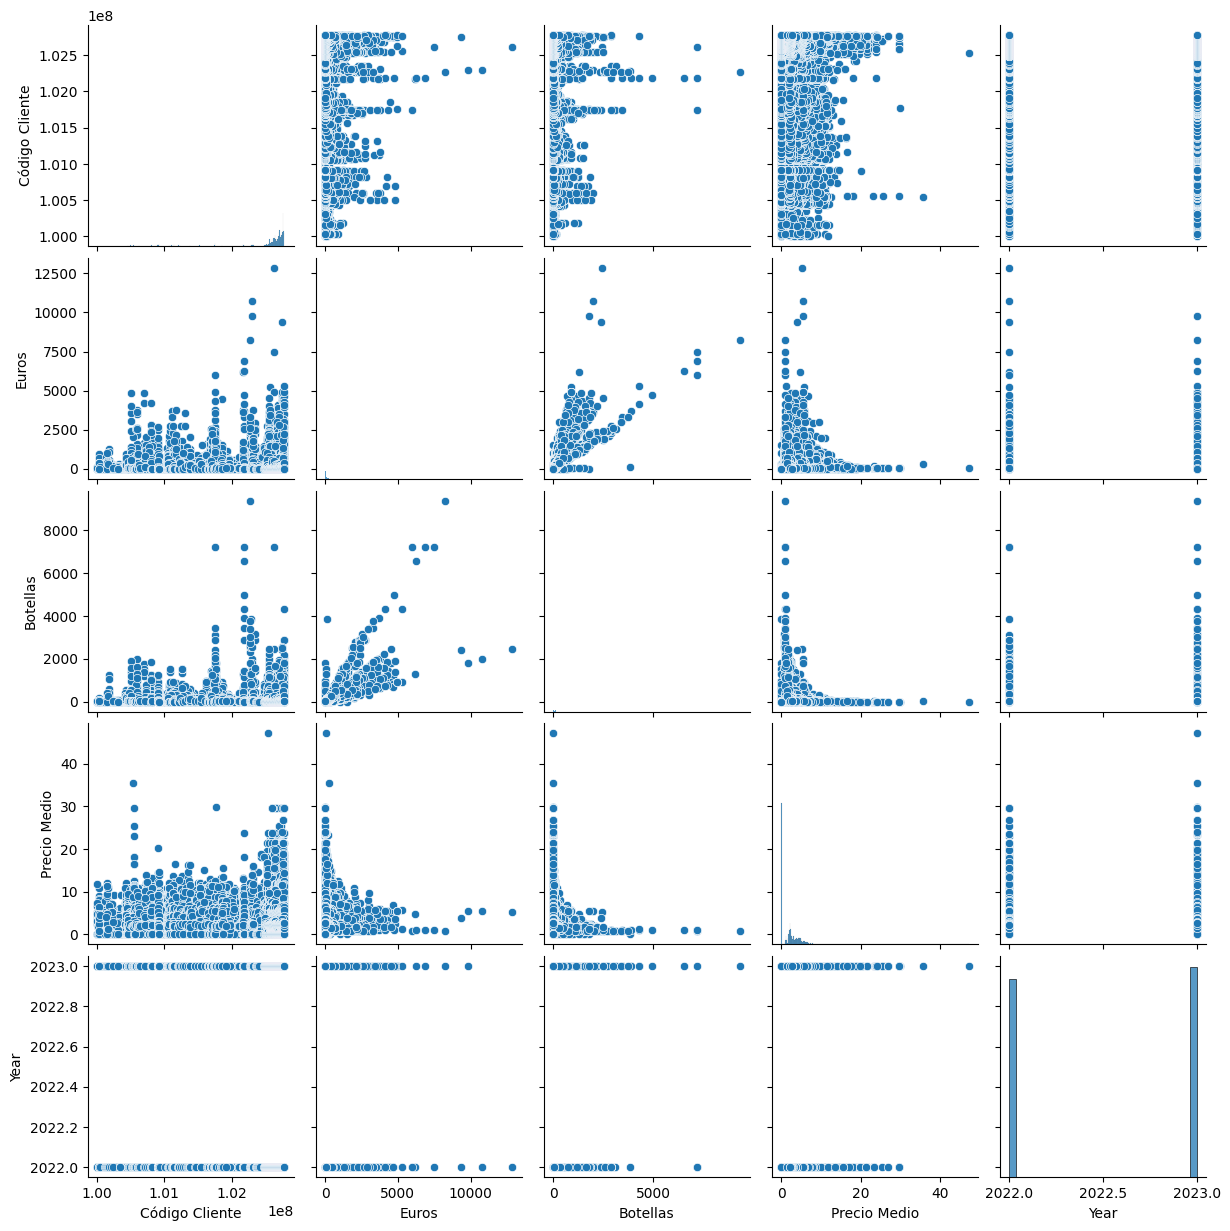

In [ ]:
sns.pairplot(data)

### Heat map (correlation matrix)

<Axes: >

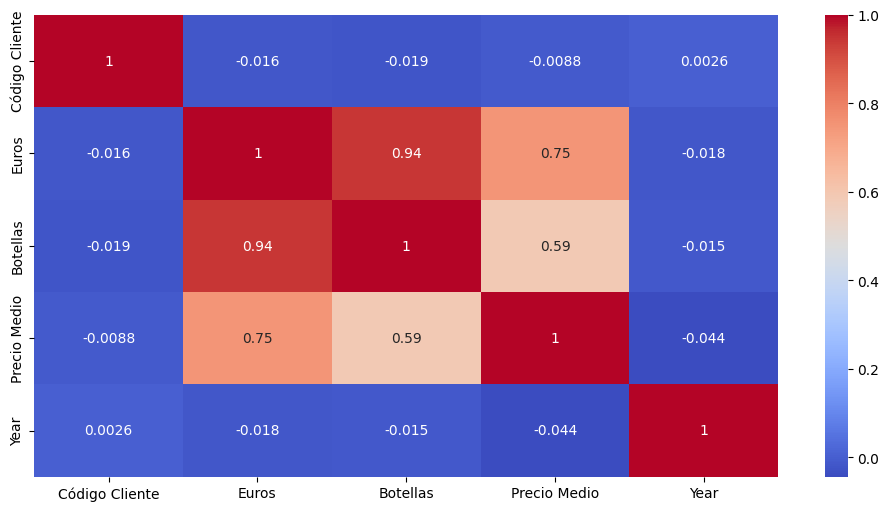

In [ ]:
#correlation matrix for numeric values only

plt.figure(figsize=(12, 6))

corr = data.corr(method='spearman', numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')

## 3.Preliminary visualizations

### Visualizacion #1: Cantidad de botellas vendidas y revenue generado en tiempo.

In [101]:
data_group_1 = data.groupby(['Año-Mes'])[['Euros', 'Botellas']].apply(sum)
data_group_1.head(2)

<ipython-input-101-1112740556>:1: FutureWarning: The provided callable <built-in function sum> is currently using np.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string np.sum instead.
  data_group_1 = data.groupby(['Año-Mes'])[['Euros', 'Botellas']].apply(sum)
/usr/local/lib/python3.11/dist-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


,Euros,Botellas
Año-Mes,,
2022-01-01,783195.03,272651.0
2022-02-01,836967.56,279485.0


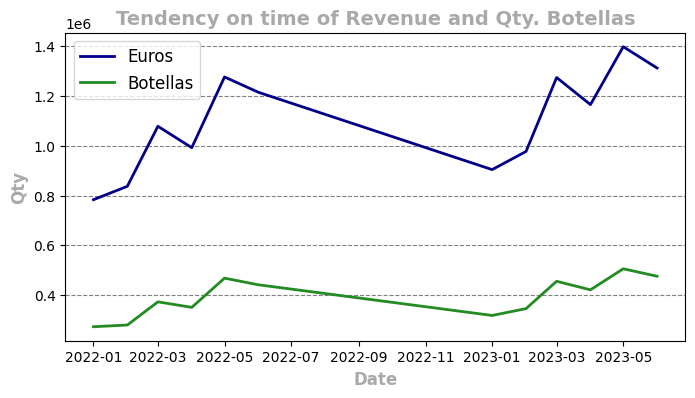

In [102]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(data_group_1.index,data_group_1['Euros'], color = "darkblue", linewidth = 2, label='Euros')
ax.plot(data_group_1.index,data_group_1['Botellas'], color = "forestgreen", linewidth = 2, label='Botellas')

ax.set_title('Tendency on time of Revenue and Qty. Botellas', loc = "Center", fontdict = {'fontsize':14, 'fontweight':'bold', 'color':'darkgray'})
ax.set_xlabel("Date", fontdict = {'fontsize':12, 'fontweight':'bold', 'color':'darkgray'})
ax.set_ylabel("Qty", fontdict = {'fontsize':12, 'fontweight':'bold', 'color':'darkgray'})
ax.legend(prop={'size': 12}, loc = 'upper left')
ax.grid(axis = 'y', color = 'gray', linestyle = 'dashed')

plt.xticks(rotation=0)

plt.show()

### Visualizacion #2: Cantidad de botellas vendidas y revenue generado, distribuidos por zona y año.

In [104]:
data_group_2 = data.pivot_table(index=['Zona', 'Year'] , values=['Euros', 'Botellas' ], aggfunc='sum')
data_group_2 = data_group_2.reset_index().sort_values(by='Euros', ascending=False)
data_group_2.head(5)

,Zona,Year,Botellas,Euros
7,Levante,2023,1410108,3655978.47
6,Levante,2022,1247498,3282843.64
9,Norte,2023,386943,1394643.16
8,Norte,2022,339875,1197617.82
3,Canarias,2023,262409,772334.45


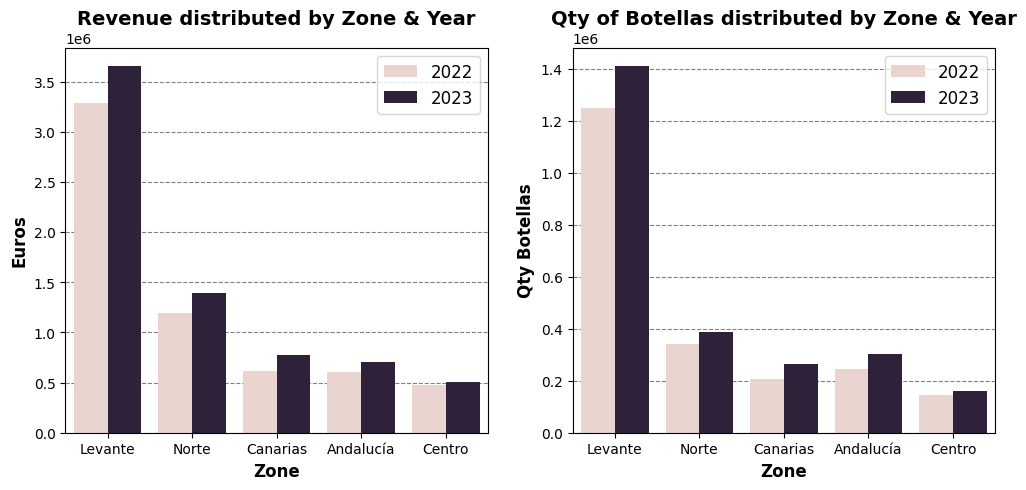

In [105]:
fig, axis=plt.subplots(ncols=2, figsize=(12, 5))

sns.barplot(data=data_group_2, x='Zona', y='Euros', hue='Year', ax=axis[0])
sns.barplot(data=data_group_2, x='Zona', y='Botellas', hue='Year', ax=axis[1])

axis[0].set_title('Revenue distributed by Zone & Year', loc = "Center", fontdict = {'fontsize':14, 'fontweight':'bold', 'color':'black'})
axis[0].set_xlabel("Zone", fontdict = {'fontsize':12, 'fontweight':'bold', 'color':'black'})
axis[0].set_ylabel("Euros", fontdict = {'fontsize':12, 'fontweight':'bold', 'color':'black'})
axis[0].legend(prop={'size': 12}, loc = 'upper right')
axis[0].grid(axis = 'y', color = 'gray', linestyle = 'dashed')
axis[0].set_axisbelow(True)

axis[1].set_title('Qty of Botellas distributed by Zone & Year', loc = "Center", fontdict = {'fontsize':14, 'fontweight':'bold', 'color':'black'})
axis[1].set_xlabel("Zone", fontdict = {'fontsize':12, 'fontweight':'bold', 'color':'black'})
axis[1].set_ylabel("Qty Botellas", fontdict = {'fontsize':12, 'fontweight':'bold', 'color':'black'})
axis[1].legend(prop={'size': 12}, loc = 'upper right')
axis[1].grid(axis = 'y', color = 'gray', linestyle = 'dashed')
axis[1].set_axisbelow(True)

plt.xticks(rotation=0)

plt.show()

### Visualizacion #3: Cantidad de botellas vendidas y revenue generado, distribuidos por tipo de establecimiento y año.

In [106]:
data_group_3 = data.pivot_table(index=['Tipo establecimiento', 'Year'] , values=['Euros', 'Botellas' ], aggfunc='sum')
data_group_3 = data_group_3.reset_index().sort_values(by='Euros', ascending=False)
data_group_3.head(5)

,Tipo establecimiento,Year,Botellas,Euros
13,RESTAURANTES,2023,975671,2949435.49
12,RESTAURANTES,2022,839402,2569220.08
3,BARES Y CAFETERIAS,2023,459148,1395365.86
2,BARES Y CAFETERIAS,2022,391290,1206680.34
1,ALOJAMIENTOS,2023,420256,1086166.69


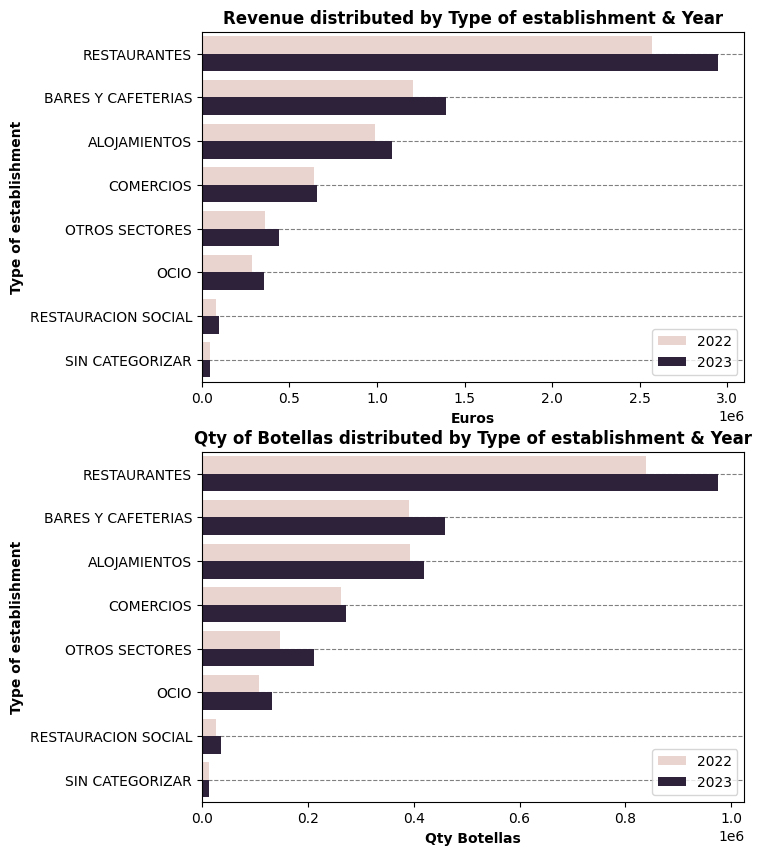

In [109]:
fig, axis=plt.subplots(ncols=1, nrows=2, figsize=(7, 10))

sns.barplot(data=data_group_3, x='Euros', y='Tipo establecimiento', hue='Year', ax=axis[0], orient='h')
sns.barplot(data=data_group_3, x='Botellas', y='Tipo establecimiento', hue='Year', ax=axis[1], orient='h')

axis[0].set_title('Revenue distributed by Type of establishment & Year', loc = "Center", fontdict = {'fontsize':12, 'fontweight':'bold', 'color':'black'})
axis[0].set_xlabel("Euros", fontdict = {'fontsize':10, 'fontweight':'bold', 'color':'black'})
axis[0].set_ylabel("Type of establishment", fontdict = {'fontsize':10, 'fontweight':'bold', 'color':'black'})
axis[0].legend(prop={'size': 10}, loc = 'lower right')
axis[0].grid(axis = 'y', color = 'gray', linestyle = 'dashed')
axis[0].set_axisbelow(True)

axis[1].set_title('Qty of Botellas distributed by Type of establishment & Year', loc = "Center", fontdict = {'fontsize':12, 'fontweight':'bold', 'color':'black'})
axis[1].set_xlabel("Qty Botellas", fontdict = {'fontsize':10, 'fontweight':'bold', 'color':'black'})
axis[1].set_ylabel("Type of establishment", fontdict = {'fontsize':10, 'fontweight':'bold', 'color':'black'})
axis[1].legend(prop={'size': 10}, loc = 'lower right')
axis[1].grid(axis = 'y', color = 'gray', linestyle = 'dashed')
axis[1].set_axisbelow(True)

plt.xticks(rotation=0)

plt.savefig("1.png")
plt.show()

### Visualizacion #4: Cantidad de botellas vendidas y revenue generado, distribuidos por marca del producto y año.

In [111]:
data_group_4 = data.pivot_table(index=['Marca', 'Year'] , values=['Euros', 'Botellas' ], aggfunc='sum')
data_group_4 = data_group_4.reset_index().sort_values(by='Euros', ascending=False)
data_group_4.head(5)

,Marca,Year,Botellas,Euros
11,Flor de Lis,2023,940375,2665436.54
10,Flor de Lis,2022,812663,2282232.41
23,Piel de Jade Especial,2023,556238,863771.01
22,Piel de Jade Especial,2022,451742,717668.55
9,Flor de Canela,2023,160198,647883.64


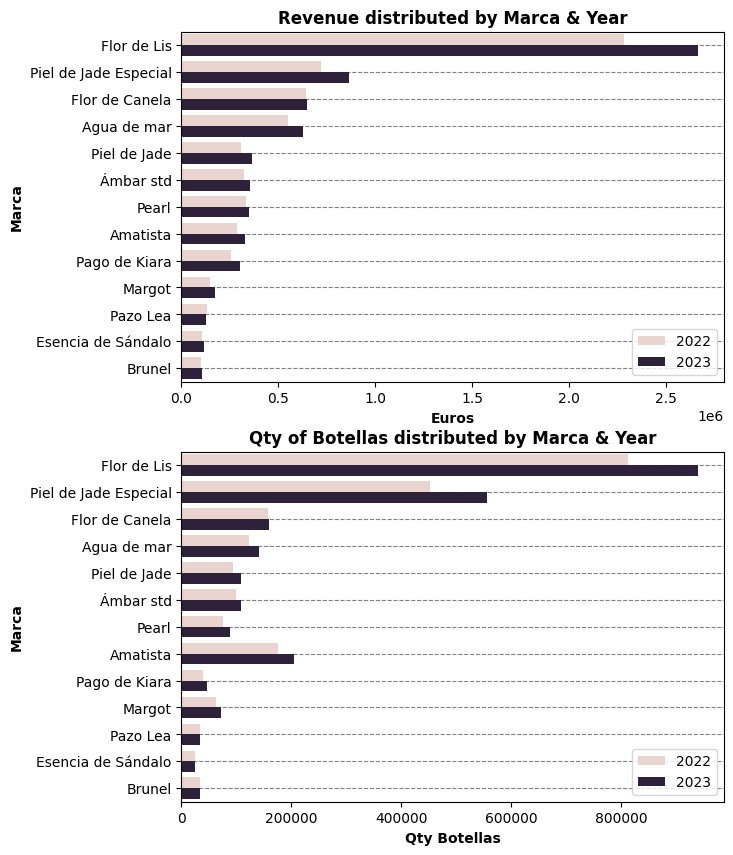

In [114]:
fig, axis=plt.subplots(ncols=1, nrows=2, figsize=(7, 10))

sns.barplot(data=data_group_4, x='Euros', y='Marca', hue='Year', ax=axis[0], orient='h')
sns.barplot(data=data_group_4, x='Botellas', y='Marca', hue='Year', ax=axis[1], orient='h')

axis[0].set_title('Revenue distributed by Marca & Year', loc = "Center", fontdict = {'fontsize':12, 'fontweight':'bold', 'color':'black'})
axis[0].set_xlabel("Euros", fontdict = {'fontsize':10, 'fontweight':'bold', 'color':'black'})
axis[0].set_ylabel("Marca", fontdict = {'fontsize':10, 'fontweight':'bold', 'color':'black'})
axis[0].legend(prop={'size': 10}, loc = 'lower right')
axis[0].grid(axis = 'y', color = 'gray', linestyle = 'dashed')
axis[0].set_axisbelow(True)

axis[1].set_title('Qty of Botellas distributed by Marca & Year', loc = "Center", fontdict = {'fontsize':12, 'fontweight':'bold', 'color':'black'})
axis[1].set_xlabel("Qty Botellas", fontdict = {'fontsize':10, 'fontweight':'bold', 'color':'black'})
axis[1].set_ylabel("Marca", fontdict = {'fontsize':10, 'fontweight':'bold', 'color':'black'})
axis[1].legend(prop={'size': 10}, loc = 'lower right')
axis[1].grid(axis = 'y', color = 'gray', linestyle = 'dashed')
axis[1].set_axisbelow(True)

plt.xticks(rotation=0)
plt.savefig("2.png")

plt.show()

### Visualizacion #5: Cantidad de botellas vendidas y revenue generado, distribuidos por familia y año.

In [115]:
data_group_5 = data.pivot_table(index=['Familia', 'Year'] , values=['Euros', 'Botellas' ], aggfunc='sum')
data_group_5 = data_group_5.reset_index().sort_values(by='Euros', ascending=False)
data_group_5.head(5)

,Familia,Year,Botellas,Euros
5,D.O. Rioja,2023,1297521,4016247.65
4,D.O. Rioja,2022,1145430,3579046.92
7,D.O. Rueda,2023,806760,1858073.62
6,D.O. Rueda,2022,669092,1572857.02
9,D.O. Somontano,2023,312053,611832.97


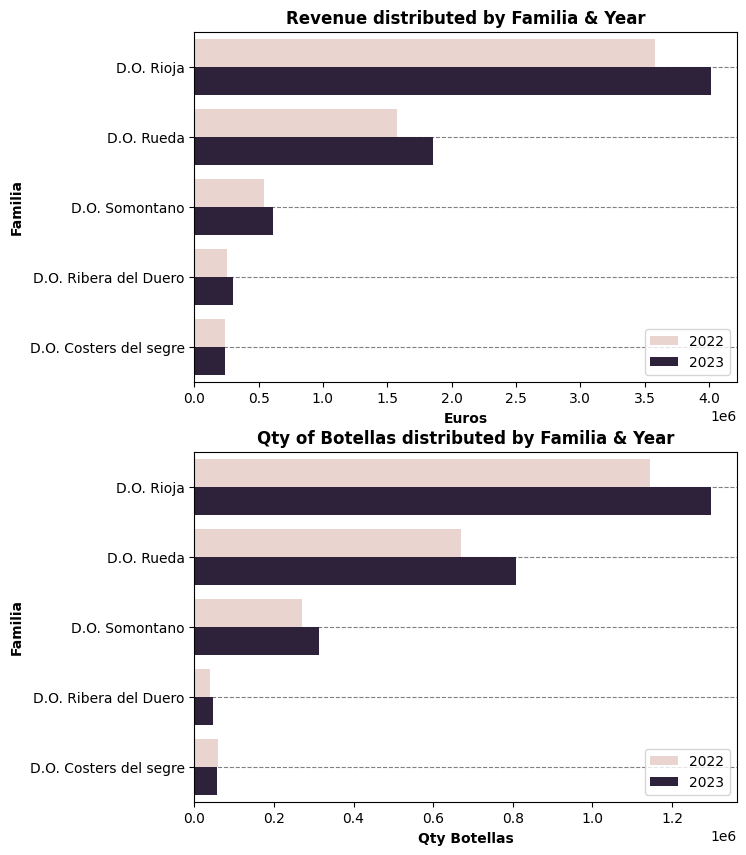

In [116]:
fig, axis=plt.subplots(ncols=1, nrows=2, figsize=(7, 10))

sns.barplot(data=data_group_5, x='Euros', y='Familia', hue='Year', ax=axis[0], orient='h')
sns.barplot(data=data_group_5, x='Botellas', y='Familia', hue='Year', ax=axis[1], orient='h')

axis[0].set_title('Revenue distributed by Familia & Year', loc = "Center", fontdict = {'fontsize':12, 'fontweight':'bold', 'color':'black'})
axis[0].set_xlabel("Euros", fontdict = {'fontsize':10, 'fontweight':'bold', 'color':'black'})
axis[0].set_ylabel("Familia", fontdict = {'fontsize':10, 'fontweight':'bold', 'color':'black'})
axis[0].legend(prop={'size': 10}, loc = 'lower right')
axis[0].grid(axis = 'y', color = 'gray', linestyle = 'dashed')
axis[0].set_axisbelow(True)

axis[1].set_title('Qty of Botellas distributed by Familia & Year', loc = "Center", fontdict = {'fontsize':12, 'fontweight':'bold', 'color':'black'})
axis[1].set_xlabel("Qty Botellas", fontdict = {'fontsize':10, 'fontweight':'bold', 'color':'black'})
axis[1].set_ylabel("Familia", fontdict = {'fontsize':10, 'fontweight':'bold', 'color':'black'})
axis[1].legend(prop={'size': 10}, loc = 'lower right')
axis[1].grid(axis = 'y', color = 'gray', linestyle = 'dashed')
axis[1].set_axisbelow(True)

plt.xticks(rotation=0)
plt.savefig("3.png")

plt.show()

### Visualizacion #6: Total de ventas por año.

In [117]:
data_group_6 = data.pivot_table(index=['Year'] , values=['Euros', 'Botellas'], aggfunc='sum')
data_group_6 = data_group_6.reset_index().sort_values(by='Euros', ascending=False)
data_group_6.head(5)

,Year,Botellas,Euros
1,2023,2520506,7030472.57
0,2022,2184251,6181670.98


In [118]:
#calculate the persentage of revenue growth and qty of saled bottles
porcentaje_0=(data_group_6['Botellas'][1] / data_group_6['Botellas'][0] * 100 - 100).round(2)
porcentaje_1=(data_group_6['Euros'][1] / data_group_6['Euros'][0] * 100 - 100).round(2)

print('Persentage of revenue growth is: ', porcentaje_1, '%')
print('Persentage of growth of saled bottles is: ', porcentaje_0, '%')

Persentage of revenue growth is:  13.73 %
Persentage of growth of saled bottles is:  15.39 %


<ipython-input-119-3474792226>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot_1=sns.barplot(data=data_group_6, x='Year', y='Euros', ax=axis[0], palette='mako')
<ipython-input-119-3474792226>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot_2=sns.barplot(data=data_group_6, x='Year', y='Botellas', ax=axis[1], palette='mako')
<ipython-input-119-3474792226>:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axis[0].legend(prop={'size': 10}, loc = 'lower right')
<ipython-input-119-3474792226>:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose labe

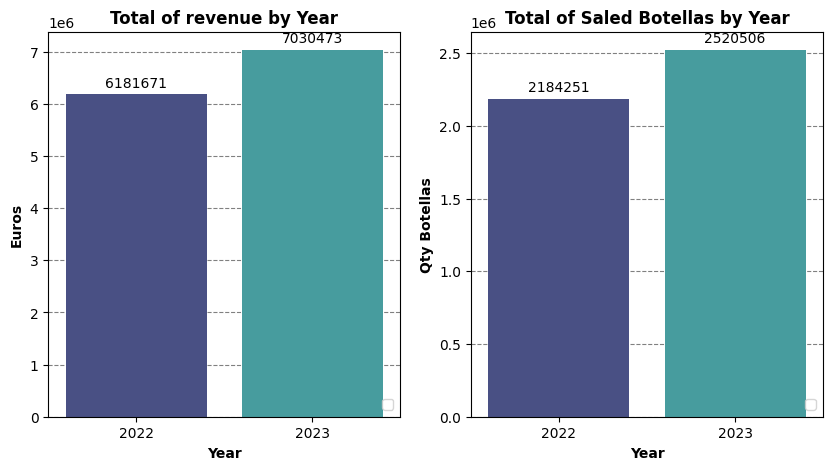

In [119]:
fig, axis=plt.subplots(ncols=2, figsize=(10, 5))

plot_1=sns.barplot(data=data_group_6, x='Year', y='Euros', ax=axis[0], palette='mako')
plot_2=sns.barplot(data=data_group_6, x='Year', y='Botellas', ax=axis[1], palette='mako')

axis[0].set_title('Total of revenue by Year', loc = "Center", fontdict = {'fontsize':12, 'fontweight':'bold', 'color':'black'})
axis[0].set_xlabel("Year", fontdict = {'fontsize':10, 'fontweight':'bold', 'color':'black'})
axis[0].set_ylabel("Euros", fontdict = {'fontsize':10, 'fontweight':'bold', 'color':'black'})
axis[0].legend(prop={'size': 10}, loc = 'lower right')
axis[0].grid(axis = 'y', color = 'gray', linestyle = 'dashed')
axis[0].set_axisbelow(True)

axis[1].set_title('Total of Saled Botellas by Year', loc = "Center", fontdict = {'fontsize':12, 'fontweight':'bold', 'color':'black'})
axis[1].set_xlabel("Year", fontdict = {'fontsize':10, 'fontweight':'bold', 'color':'black'})
axis[1].set_ylabel("Qty Botellas", fontdict = {'fontsize':10, 'fontweight':'bold', 'color':'black'})
axis[1].legend(prop={'size': 10}, loc = 'lower right')
axis[1].grid(axis = 'y', color = 'gray', linestyle = 'dashed')
axis[1].set_axisbelow(True)

# Añadir etiquetas a las barras de Euros
for container in plot_1.containers:
    plot_1.bar_label(container, fmt='%.0f', label_type='edge', padding=3)

# Añadir etiquetas a las barras de Botellas
for container in plot_2.containers:
    plot_2.bar_label(container, fmt='%.0f', label_type='edge', padding=3)

plt.xticks(rotation=0)

plt.show()

## 4.Conclusiones.

Despues de realizado el analisis exploratorio de los datos, se puedo concluir lo siguiente:
1. Entre los años 2022 y 2023 existe una tendencia positiva de crecimiento de negocio, tanto en cantidad de botellas vendidas (15.39%) como en el valor de revenue generado (13.73%).
2. Se determina que existe una relacion fuerte entre Familia y el producto que se adquiere.
3. Se observan los picos de venta de las botellas de vino en los meses de mayo, siendo enero - el mes con las ventas mas bajas. En la data proporcionada no existen registros en los meses julio-diciembre.
4. La zona con mayor cantidad de botellas vendidas - Levante (55.95% en el año 2023), y con las ventas mas bajas - Centro.
5. La marca del producto más vendido - Flor de Lis, y menos vendido - Brunel.
6. El tipo de establecimiento (canal de distribución) con mayor cantidad de ventas es Restaurante seguido por bares y cafeterias.
7. Las botellas de vino tipo Premiun se distribuyen mas a los restaurantes, bares y cafeterias. Las botellas de categoria estandar tienen la mayor presencia en el mercado.

El plan de accion propuesto es el siguiente:
1. Investigar la temporalidad en las ventas y los factores que influyen, definir los canales de distribucion y el producto más vendido en la temporada alta para incrementar las ventas. De la misma manera se sugiere realizar la investigacion de porque hay un decremento de ventas en los primeros meses del año y de ser el caso - vender el producto que mas se adapte a las necesidades de la población.
2. Expandir la presencia en las regiones con más ventas. Realizar el estudio de mercado en las zonas con las ventas bajas, aplicar las estrategias de marketing para mejorar la presencia y aumentar las ventas.
3. Analizar el precio medio por producto y por categoria del producto. Los productos de la misma categoria deberian estar en un rango parecido de precios.

Se recomienda realizar el monitoreo continuo del avance de la implementacion de los puntos sugeridos.

A continuacion se presenta el dashboard desarrollado en Power BI para presentar a Gerencia de la empresa vinícola.

![Actividad 2. Dashboard. Tatiana Kraseliuk.png](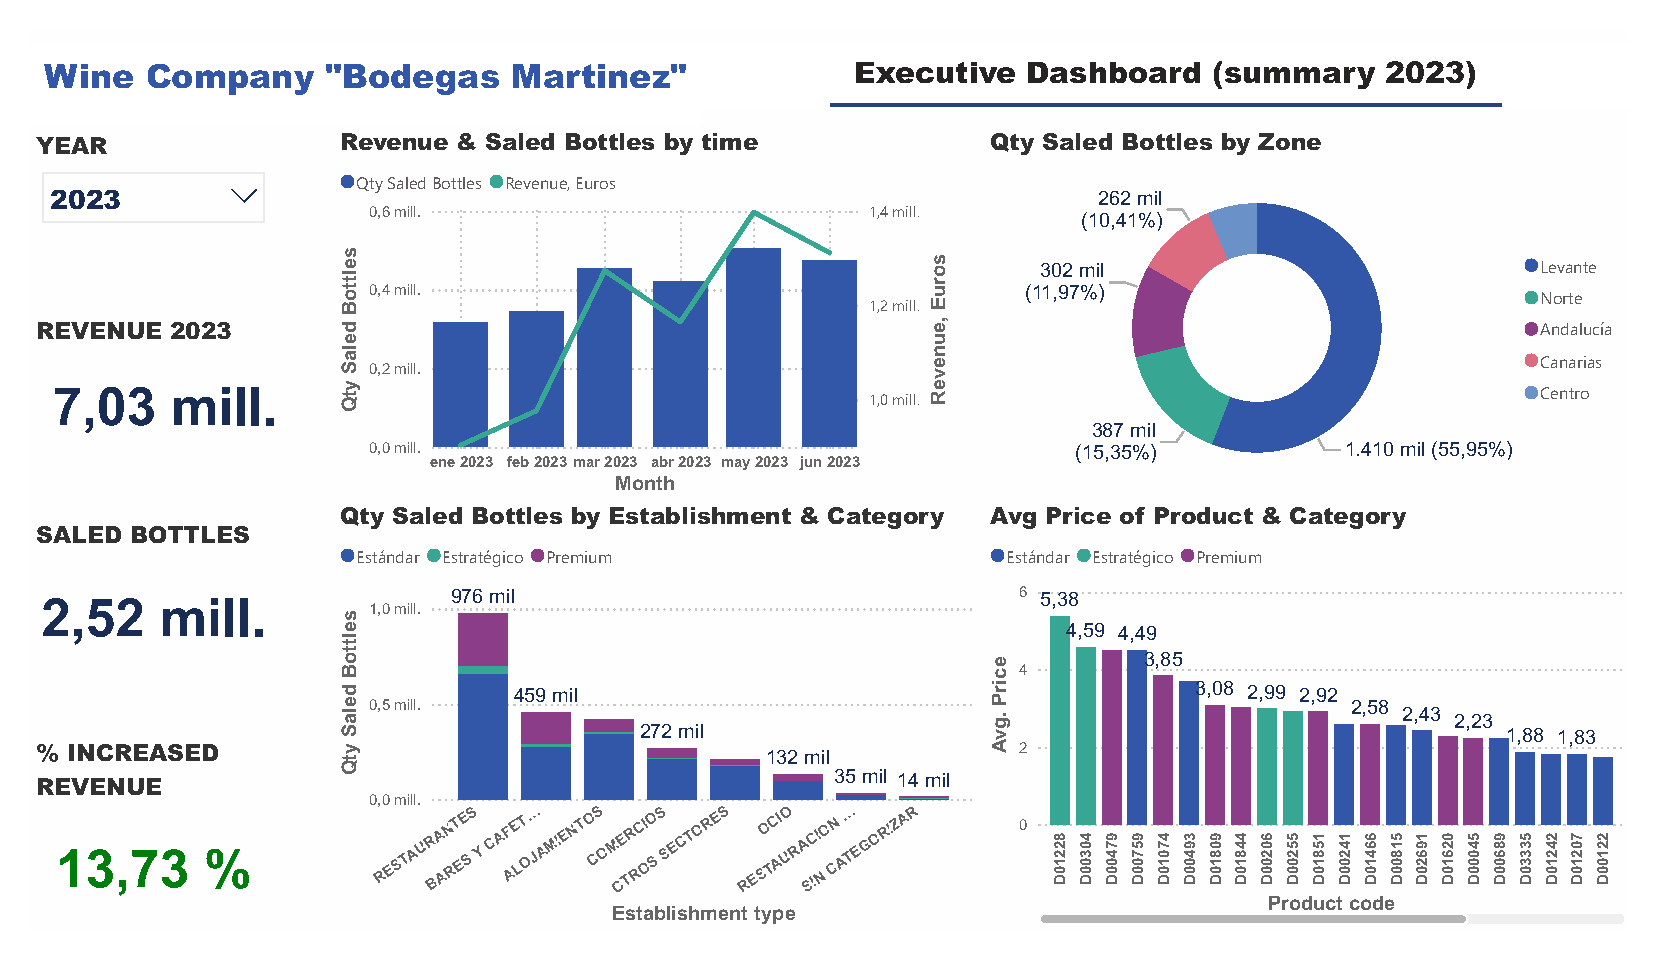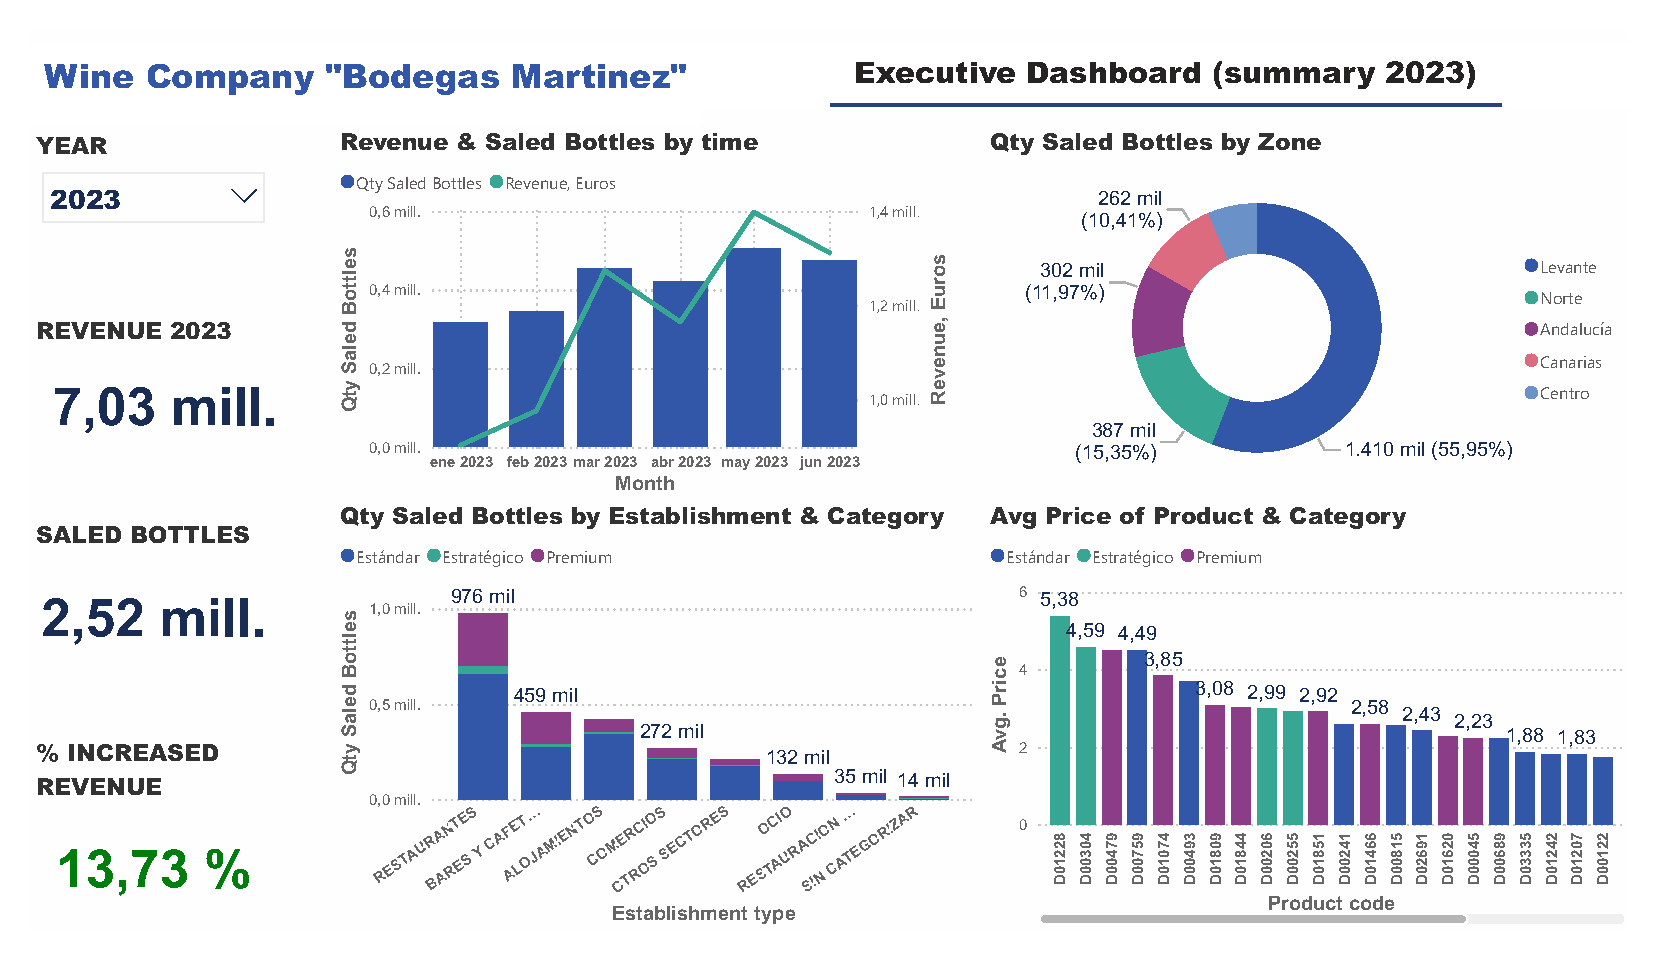)